# Waypoint inference tutorial (single example)


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

def find_root_path(path: str, word: str):
    parts = path.split(word, 1)
    return parts[0] + word if len(parts) > 1 else path

root_folder = Path(find_root_path(os.getcwd(), 'art_lang'))
sys.path.append(str(root_folder))

from rpod.optimization.optimization import NonConvexOCP
from rpod.optimization.scvx import solve_scvx
import rpod.optimization.parameters as param
from rpod.dynamics.dynamics_trans import propagate_oe, propagate_ct
from rpod.rages.train_wyp_predictor import (
    ConditionalGMM,
    ConditionalVAE,
    constrained_fill,
    scale_var,
    unscale_var,
    FillerConfig,
    build_input_from_data,
    build_input_slices,
)
from rpod.rages.datagen_wyp import BEHAVIOR_IDS, _waypoint_times_from_dts


In [2]:
# Load trained model
ckpt_path = root_folder / 'rpod' / 'rages' / 'wyp_model' / 'model_gmm_v3_unweighted_one_hot.pt'
try:
    ckpt = torch.load(ckpt_path, map_location='cpu')
except AttributeError as e:
    raise RuntimeError(
        'Checkpoint was saved with cfg pickled from __main__. Re-run training to resave with cfg dict.'
    ) from e

cfg_raw = ckpt['cfg']
if isinstance(cfg_raw, dict):
    cfg_dict = dict(cfg_raw)
else:
    cfg_dict = dict(vars(cfg_raw))

from dataclasses import MISSING
for name, field in FillerConfig.__dataclass_fields__.items():
    if name not in cfg_dict and field.default is not MISSING:
        cfg_dict[name] = field.default

fields = set(FillerConfig.__dataclass_fields__.keys())
filtered = {k: v for k, v in cfg_dict.items() if k in fields}
cfg = FillerConfig(**filtered)

model_type = ckpt.get('model_type', 'gmm')
if model_type == 'vae':
    model = ConditionalVAE(cfg)
else:
    model = ConditionalGMM(cfg)

model.load_state_dict(ckpt['model_state_dict'])
model.eval()

y_mean = ckpt['y_mean']
y_std = ckpt['y_std']
X_mean = ckpt['X_mean']
X_std = ckpt['X_std']
inputs_arg = ckpt.get('inputs_arg', ['x0','tof','oec0_modified','artms_scale_range_1e3','koz_dim','b_seq'])
b_seq_encoding = getattr(cfg, 'b_seq_encoding', 'scalar')
b_seq_num_classes = int(getattr(cfg, 'b_seq_num_classes', 11))

print(b_seq_encoding, b_seq_num_classes)


one_hot 11


In [4]:
# Pick one example from the dataset (.pth)
data_path = root_folder / 'rpod' / 'rages' / 'wyp_data' / 'data_v3_discrete.pth'
dataset = torch.load(data_path, map_location='cpu')
data = dataset['data']
meta = dataset['meta']

idx = 41

x0 = data['x0'][idx].numpy()
b_seq_full = data['b_seq'][idx].numpy()
phase_valid = data['phase_valid'][idx].numpy().astype(bool)
b_seq = b_seq_full[phase_valid].astype(int).tolist()
tof = int(data['tof'][idx].item())
dt_seq = data['dt_seq'][idx].numpy()
koz_dim = data['koz_dim'][idx].numpy()
artms_scale_range_1e3 = data['artms_scale_range_1e3'][idx].numpy()
oec0_mod = data['oec0_modified'][idx].numpy()

beh_seq_str = ' -> '.join([BEHAVIOR_IDS[b] for b in b_seq]) if b_seq else '[]'
print('Selected example behavior sequence:', beh_seq_str)
print('initial state x0:', x0)
print('true dt_seq (steps):', dt_seq, 'total tof (steps):', tof)
print('koz_dim:', koz_dim)
print('artms_scale_range_1e3:', artms_scale_range_1e3)

max_phase = cfg.max_phase
phase_valid_t = torch.tensor(phase_valid, dtype=torch.float32).unsqueeze(0)

# build empty inputs for prediction (all missing)
y_dim = max_phase * 6 + max_phase
y_in = torch.zeros(1, y_dim)
m_known = torch.zeros(1, y_dim)

x_full = build_input_from_data(
    data,
    idx,
    inputs_arg,
    b_seq_encoding=b_seq_encoding,
    b_seq_num_classes=b_seq_num_classes,
).unsqueeze(0)
x_full = scale_var(x_full, X_mean, X_std)
input_slices = build_input_slices(
    data,
    inputs_arg,
    b_seq_encoding=b_seq_encoding,
    b_seq_num_classes=b_seq_num_classes,
)
# mask padded b entries after scaling
if 'b_seq' in input_slices:
    b_slice = input_slices['b_seq']
    b_width = int(b_slice.stop - b_slice.start)
    if b_width == int(max_phase):
        b_phase_valid = phase_valid_t
    elif b_width % int(max_phase) == 0:
        rep = b_width // int(max_phase)
        b_phase_valid = phase_valid_t.repeat_interleave(rep, dim=-1)
    else:
        raise ValueError(f'b_seq input width {b_width} is incompatible with max_phase={max_phase}.')
    x_full[:, b_slice.start:b_slice.stop] = x_full[:, b_slice.start:b_slice.stop] * b_phase_valid

with torch.no_grad():
    y_scaled = model.sample_y(x_full, y_in, m_known, cfg, 
                              phase_valid=phase_valid_t, use_mean_w=True)
    y_unscaled = unscale_var(y_scaled, y_mean, y_std)

# fill missing with time allocation constraint
tof_raw_t = torch.tensor([[tof]], dtype=torch.float32)
y_filled = constrained_fill(y_unscaled, y_in, m_known, tof_raw_t, cfg, phase_valid=phase_valid_t)

# extract predictions
x_pred = y_filled[0, : max_phase * 6].reshape(max_phase, 6).numpy()
dt_pred = y_filled[0, max_phase * 6 :].numpy()

# keep only valid phases
x_pred = x_pred[:len(b_seq)]
dt_pred = dt_pred[:len(b_seq)]

print('Predicted phase durations (steps):', np.round(dt_pred, 2))
print('waypoint predictions: ', np.round(x_pred, 2))


Selected example behavior sequence: Expand R/N separation -> Drift +V-direction -> Station-Keeping
initial state x0: [   0.  -100.     0.    -2.5    0.    -2.5]
true dt_seq (steps): [0.28282827 0.44444445 0.27272728] total tof (steps): 99
koz_dim: [20. 20. 20.]
artms_scale_range_1e3: [0.0002 0.008  0.004  0.004  0.004  0.004 ]
Predicted phase durations (steps): [0.24 0.52 0.24]
waypoint predictions:  [[  -0.   -151.3     0.     51.01   -0.     51.05]
 [   0.    158.63   -0.     49.33    0.     50.1 ]
 [  -0.    154.67   -0.     47.9     0.     49.08]]


In [5]:
# build time grid from predicted dt (steps -> seconds)
dt_sec = float(meta.get('dt_sec', param.dt_sec))
tof_steps = int(tof)
n_time = tof_steps + 1
tvec_sec = np.arange(n_time, dtype=float) * dt_sec
oec0 = param.oec0

# map predicted phase durations to discrete waypoint indices
t_idx_wyp = _waypoint_times_from_dts(list(dt_pred), n_time)

# waypoints exclude the final state; final state is the goal
wyp = x_pred[:-1] if len(x_pred) > 1 else np.empty((0, 6))
goal = x_pred[-1] if len(x_pred) > 0 else x0

current_obs = {
    'state': x0,
    'goal': goal,
    'ttg': tvec_sec[-1],
    'dt': dt_sec,
    'oe': oec0,
}

prob = NonConvexOCP(
    prob_definition={
        't_i': 0,
        't_f': n_time,
        'tvec_sec': tvec_sec,
        'chance': False,
        'current_obs': current_obs,
        'waypoint_times': t_idx_wyp,
        'waypoints': wyp,
        'waypoint_type': 'roe',
        'ct': True,
        'koz_dim': koz_dim,
        'artms_scale_range_1e3': artms_scale_range_1e3,
    }
)

sol_cvx = prob.ocp_cvx()
print('cvx status:', sol_cvx['status'])
roe_cvx = sol_cvx['z']['state']
u_cvx = sol_cvx['z']['action']
oec = propagate_oe(oec0, tvec_sec)
rtn_cvx = prob.f_2rtn(roe_cvx, oec)
_, _, rtn_cvx_ct = propagate_ct(roe_cvx, u_cvx, oec, tvec_sec, n=10)


cvx status: optimal


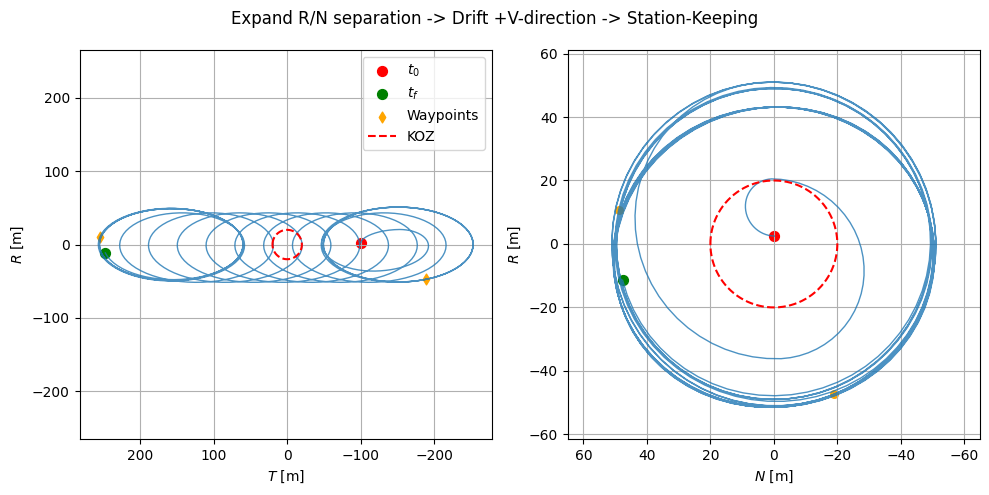

In [6]:
# plot trajectory (same style as test_wyp.ipynb)
phi = np.linspace(0, 2 * np.pi, 100)
x_circ = koz_dim[0] * np.cos(phi)
y_circ = koz_dim[0] * np.sin(phi)

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot(rtn_cvx_ct[:, 1], rtn_cvx_ct[:, 0], linewidth=1, alpha=0.8)
ax2.plot(rtn_cvx_ct[:, 2], rtn_cvx_ct[:, 0], linewidth=1, alpha=0.8)

# boundary state 
ax1.scatter(rtn_cvx_ct[0, 1], rtn_cvx_ct[0, 0], color='r', s=50, label='$t_0$')
ax2.scatter(rtn_cvx_ct[0, 2], rtn_cvx_ct[0, 0], color='r', s=50, )
ax1.scatter(rtn_cvx_ct[-1, 1], rtn_cvx_ct[-1, 0], color='g', s=50, label='$t_f$')
ax2.scatter(rtn_cvx_ct[-1, 2], rtn_cvx_ct[-1, 0], color='g', s=50, )
if len(t_idx_wyp) > 0:
    ax1.scatter(rtn_cvx[t_idx_wyp, 1], rtn_cvx[t_idx_wyp, 0], color='orange', marker='d', s=30, label='Waypoints')
    ax2.scatter(rtn_cvx[t_idx_wyp, 2], rtn_cvx[t_idx_wyp, 0], color='orange', s=30, )

ax1.plot(x_circ, y_circ, color='r', linestyle='--', label='KOZ')
ax1.set_xlabel('$T$ [m]')
ax1.set_ylabel('$R$ [m]')
ax1.invert_xaxis()
ax1.grid()
ax1.axis('equal')

ax2.plot(x_circ, y_circ, color='r', linestyle='--', label='KOZ')
ax2.set_xlabel('$N$ [m]')
ax2.set_ylabel('$R$ [m]')
ax2.invert_xaxis()
ax2.grid()
ax2.axis('equal')

ax1.legend()

fig.suptitle(beh_seq_str)

plt.tight_layout()
plt.show()


In [7]:
# --- New: policy sweep + scenario generation ---
from rpod.rages.datagen_wyp import (
    NODES,
    POLICY_REGISTRY,
    enumerate_policy_paths,
    DT_SEC, N_TIME_MAX, _time_grid_from_orbits,
)

def _in_range(x, r, tol=0.0):
    return (r[0] - tol) <= x <= (r[1] + tol)

def _in_multirange(x, r, tol=0.0):
    if isinstance(r[0], (list, tuple)):
        return any(_in_range(x, rr, tol=tol) for rr in r)
    return _in_range(x, r, tol=tol)

def classify_orbital_domain(state, nodes=NODES, tol=1e-6):
    dl = float(state[1])
    dey = float(state[3])
    matches = []
    for name, vol in nodes.items():
        if _in_range(dl, vol.d_lambda_range, tol=tol) and _in_multirange(dey, vol.d_ex_range, tol=tol):
            matches.append(name)
    return matches

def generate_behavior_scenarios(x0, M, max_phase, seed=1):
    start_nodes = classify_orbital_domain(x0)
    if not start_nodes:
        return []
    start_node = start_nodes[0]

    all_sequences = []
    for name, pol in POLICY_REGISTRY.items():
        if start_node not in pol.get_valid_start_nodes():
            continue
        seqs = enumerate_policy_paths(pol, start_node, max_steps=max_phase)
        for beh_seq, dt_ranges in seqs:
            if 0 < len(beh_seq) <= max_phase:
                all_sequences.append((name, beh_seq, dt_ranges))

    if not all_sequences:
        return []

    rng = np.random.default_rng(seed)
    scenarios = []
    for _ in range(M):
        name, beh_seq, dt_ranges = all_sequences[int(rng.integers(len(all_sequences)))]
        dt_orbits = [float(rng.uniform(lo, hi)) for (lo, hi) in dt_ranges]
        total_orbits = float(np.sum(dt_orbits))
        n_time, _ = _time_grid_from_orbits(total_orbits, DT_SEC, N_TIME_MAX, param.oec0[0])
        tof_steps = int(n_time - 1)
        scenarios.append({
            "policy": name,
            "b_seq": beh_seq,
            "tf_orbits": total_orbits,
            "tof_steps": tof_steps,
            "dt_orbits": dt_orbits,
        })
    return scenarios

start_domains = classify_orbital_domain(x0)
print("classified domain(s) for x0:", start_domains)


classified domain(s) for x0: ['e_Neg_Flat']


In [8]:
# --- New: generate M scenarios and run inference + trajectory solve ---
input_slices = build_input_slices(
    data,
    inputs_arg,
    b_seq_encoding=b_seq_encoding,
    b_seq_num_classes=b_seq_num_classes,
)


def build_data_from_values(values, max_phase):
    data = {}
    data["x0"] = torch.as_tensor(values["x0"], dtype=torch.float32).reshape(1, -1)
    data["tof"] = torch.as_tensor([[values["tof"]]], dtype=torch.float32)
    data["oec0_modified"] = torch.as_tensor(values["oec0_modified"], dtype=torch.float32).reshape(1, -1)
    data["artms_scale_range_1e3"] = torch.as_tensor(values["artms_scale_range_1e3"], dtype=torch.float32).reshape(1, -1)
    data["koz_dim"] = torch.as_tensor(values["koz_dim"], dtype=torch.float32).reshape(1, -1)
    b_pad = np.zeros((1, max_phase), dtype=np.float32)
    b_seq = np.asarray(values["b_seq"], dtype=np.float32)
    b_pad[0, : min(len(b_seq), max_phase)] = b_seq[: max_phase]
    data["b_seq"] = torch.as_tensor(b_pad, dtype=torch.float32)
    if "x_seq" in values:
        data["x_seq"] = torch.as_tensor(values["x_seq"], dtype=torch.float32).reshape(1, max_phase, 6)
    return data


def run_wyp_inference_for_sequence(x0, tof_steps, b_seq, oec0_mod, artms, koz_dim):
    max_phase = cfg.max_phase
    phase_valid = np.zeros(max_phase, dtype=bool)
    phase_valid[: len(b_seq)] = True
    phase_valid_t = torch.tensor(phase_valid, dtype=torch.float32).unsqueeze(0)

    y_dim = max_phase * 6 + max_phase
    y_in = torch.zeros(1, y_dim)
    m_known = torch.zeros(1, y_dim)

    values = {
        "x0": x0,
        "tof": tof_steps,
        "oec0_modified": oec0_mod,
        "artms_scale_range_1e3": artms,
        "koz_dim": koz_dim,
        "b_seq": b_seq,
    }
    data_like = build_data_from_values(values, max_phase)
    x_full = build_input_from_data(
        data_like,
        0,
        inputs_arg,
        b_seq_encoding=b_seq_encoding,
        b_seq_num_classes=b_seq_num_classes,
    ).unsqueeze(0)

    x_full = scale_var(x_full, X_mean, X_std)
    if "b_seq" in input_slices:
        b_slice = input_slices["b_seq"]
        b_width = int(b_slice.stop - b_slice.start)
        if b_width == int(max_phase):
            b_phase_valid = phase_valid_t
        elif b_width % int(max_phase) == 0:
            rep = b_width // int(max_phase)
            b_phase_valid = phase_valid_t.repeat_interleave(rep, dim=-1)
        else:
            raise ValueError(f"b_seq input width {b_width} is incompatible with max_phase={max_phase}.")
        x_full[:, b_slice.start : b_slice.stop] = x_full[:, b_slice.start : b_slice.stop] * b_phase_valid

    with torch.no_grad():
        y_scaled = model.sample_y(x_full, y_in, m_known, cfg, phase_valid=phase_valid_t)
        y_unscaled = unscale_var(y_scaled, y_mean, y_std)

    tof_raw_t = torch.tensor([[tof_steps]], dtype=torch.float32)
    y_filled = constrained_fill(y_unscaled, y_in, m_known, tof_raw_t, cfg, phase_valid=phase_valid_t)

    x_pred = y_filled[0, : max_phase * 6].reshape(max_phase, 6).numpy()
    dt_pred = y_filled[0, max_phase * 6 :].numpy()

    x_pred = x_pred[: len(b_seq)]
    dt_pred = dt_pred[: len(b_seq)]

    return x_pred, dt_pred


def solve_trajectory_from_prediction(x0, x_pred, dt_pred, tof_steps, koz_dim, artms):
    dt_sec = float(meta.get("dt_sec", param.dt_sec))
    n_time = int(tof_steps) + 1
    if n_time < 2:
        return "invalid_tof", "invalid_tof", None, None, None

    tvec_sec = np.arange(n_time, dtype=float) * dt_sec
    oec0 = param.oec0

    t_idx_wyp = _waypoint_times_from_dts(list(dt_pred), n_time)

    wyp = x_pred[:-1] if len(x_pred) > 1 else np.empty((0, 6))
    goal = x_pred[-1] if len(x_pred) > 0 else x0

    current_obs = {
        "state": x0,
        "goal": goal,
        "ttg": tvec_sec[-1],
        "dt": dt_sec,
        "oe": oec0,
    }

    prob = NonConvexOCP(
        prob_definition={
            "t_i": 0,
            "t_f": n_time,
            "tvec_sec": tvec_sec,
            "chance": True,
            "ct": False,
            "current_obs": current_obs,
            "waypoint_times": t_idx_wyp,
            "waypoints": wyp,
            "waypoint_type": "roe",
            "koz_dim": koz_dim,
            "artms_scale_range_1e3": artms,
        }
    )

    sol_cvx = prob.ocp_cvx()
    status_cvx = sol_cvx["status"]
    if status_cvx not in ["optimal", "optimal_inaccurate"]:
        return status_cvx, "cvx_failed", None, None, None

    roe_cvx = sol_cvx["z"]["state"]
    actions_cvx = sol_cvx["z"]["action"]

    prob.zref = {"state": roe_cvx, "action": actions_cvx}
    prob.sol_0 = {"z": prob.zref}
    prob.generate_scaling(roe_cvx, actions_cvx)
    sol_scp, _ = solve_scvx(prob)
    status_scp = sol_scp["status"]
    if status_scp not in ["optimal", "optimal_inaccurate"]:
        return status_cvx, status_scp, None, None, None

    roe_scp = sol_scp["z"]["state"]
    actions_scp = sol_scp["z"]["action"]
    oec = propagate_oe(oec0, tvec_sec)
    rtn_scp = prob.f_2rtn(roe_scp, oec)
    _, _, rtn_scp_ct = propagate_ct(roe_scp, actions_scp, oec, tvec_sec, n=10)

    return status_cvx, status_scp, rtn_scp_ct, rtn_scp, t_idx_wyp

M = 5
scenarios = generate_behavior_scenarios(x0, M, max_phase=cfg.max_phase, seed=4)
print(f"generated {len(scenarios)} scenarios")

results = []
for i, sc in enumerate(scenarios):
    b_seq = sc["b_seq"]
    x_pred, dt_pred = run_wyp_inference_for_sequence(
        x0=x0,
        tof_steps=sc["tof_steps"],
        b_seq=b_seq,
        oec0_mod=oec0_mod,
        artms=artms_scale_range_1e3,
        koz_dim=koz_dim,
    )
    status_cvx, status_scp, rtn_scp_ct, rtn_scp, t_idx_wyp = solve_trajectory_from_prediction(
        x0=x0,
        x_pred=x_pred,
        dt_pred=dt_pred,
        tof_steps=sc["tof_steps"],
        koz_dim=koz_dim,
        artms=artms_scale_range_1e3,
    )

    beh_seq_str = " -> ".join([BEHAVIOR_IDS[b] for b in b_seq]) if b_seq else "[]"
    print(f"[{i}] policy={sc['policy']} tf_orbits={sc['tf_orbits']:.2f} cvx={status_cvx} scp={status_scp} seq={beh_seq_str}")

    results.append({
        "b_seq": b_seq,
        "status_cvx": status_cvx,
        "status_scp": status_scp,
        "scenario": sc,
        "x_pred": x_pred,
        "dt_pred": dt_pred,
        "rtn_scp_ct": rtn_scp_ct,
        "rtn_scp": rtn_scp,
        "t_idx_wyp": t_idx_wyp,
    })

ok = [r for r in results if r["rtn_scp_ct"] is not None]
print(f"solved {len(ok)} / {len(results)} trajectories (cvx+scp)")


generated 5 scenarios
[0] policy=FLYBY tf_orbits=15.68 cvx=optimal scp=optimal seq=Expand R/N separation -> Drift +V-direction -> Shrink R/N separation
[1] policy=DUCKING tf_orbits=4.74 cvx=optimal scp=optimal seq=Ducking (fast drift) +V-direction -> Expand R/N separation
[2] policy=FLYBY tf_orbits=15.64 cvx=optimal scp=optimal seq=Expand R/N separation -> Drift +V-direction -> Shrink R/N separation
[3] policy=DUCKING tf_orbits=5.33 cvx=optimal scp=optimal seq=Ducking (fast drift) +V-direction -> Station-Keeping
[4] policy=DUCKING tf_orbits=6.74 cvx=optimal scp=optimal seq=Ducking (fast drift) +V-direction -> Expand R/N separation
solved 5 / 5 trajectories (cvx+scp)


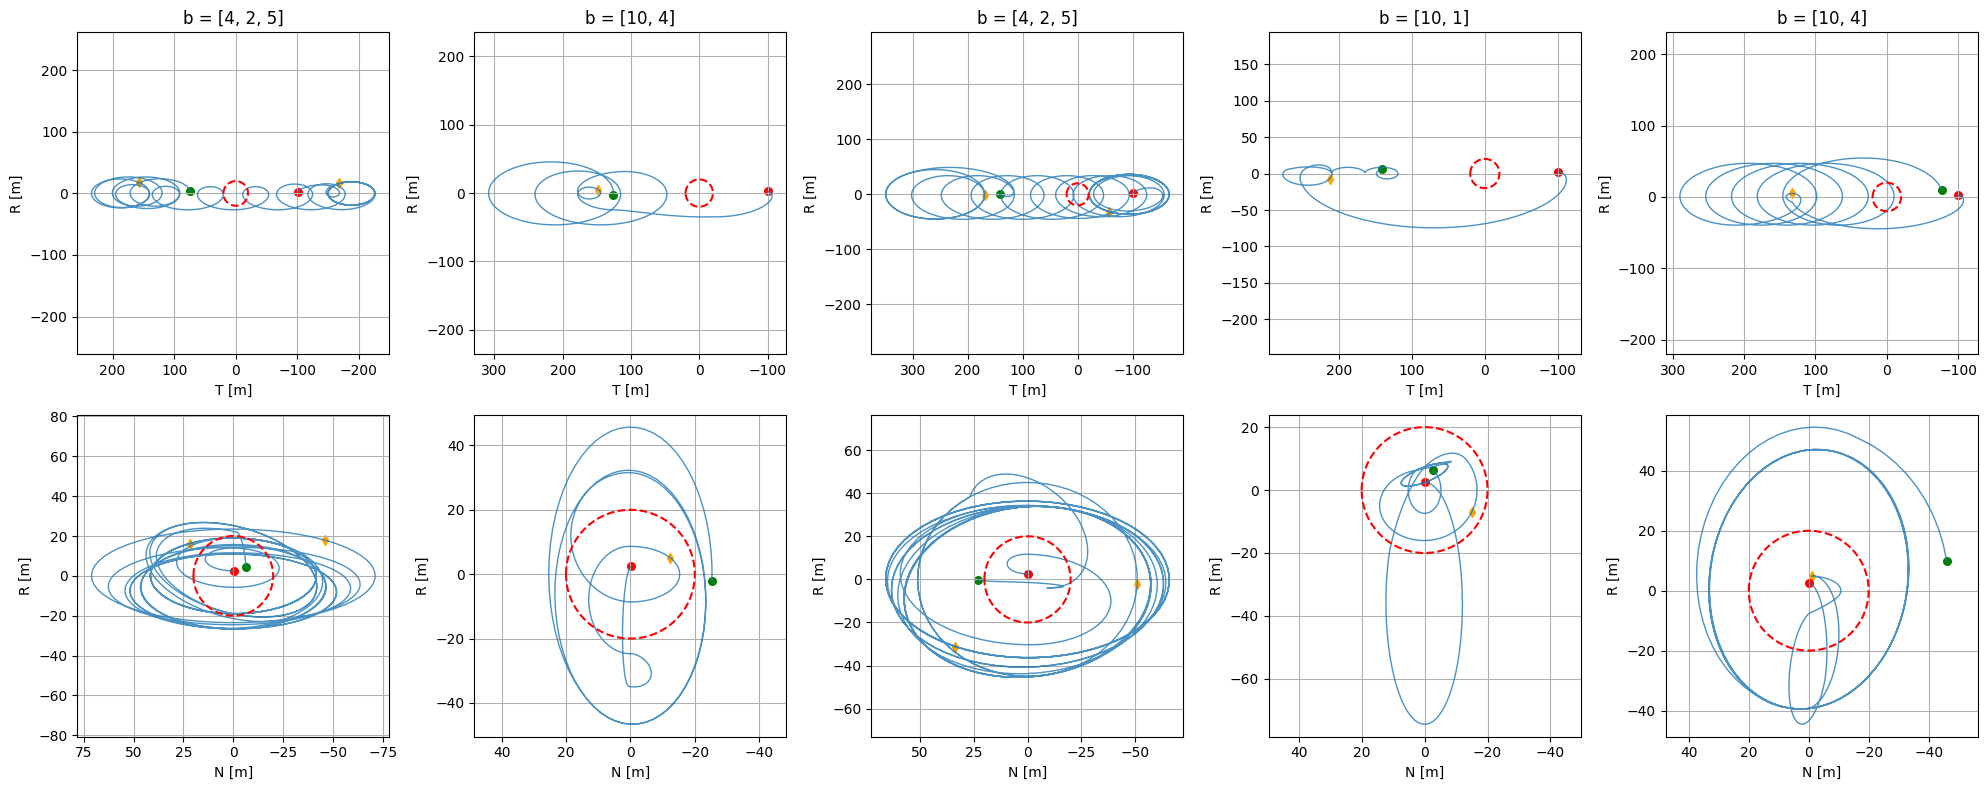

In [9]:
# --- New: plot all trajectories in a 2 x M horizontal layout ---
import matplotlib.pyplot as plt

def plot_trajectories_grid(results, koz_dim):
    ok = [r for r in results if r.get("rtn_scp_ct") is not None]
    M = len(ok)
    if M == 0:
        print("No trajectories to plot.")
        return

    phi = np.linspace(0, 2 * np.pi, 100)
    x_circ = koz_dim[0] * np.cos(phi)
    y_circ = koz_dim[0] * np.sin(phi)

    fig, axes = plt.subplots(2, M, figsize=(4 * M, 8), squeeze=False)

    for i, r in enumerate(ok):
        traj = r["rtn_scp_ct"]

        ax_rt = axes[0, i]
        ax_rn = axes[1, i]

        ax_rt.plot(traj[:, 1], traj[:, 0], linewidth=1, alpha=0.8)
        ax_rn.plot(traj[:, 2], traj[:, 0], linewidth=1, alpha=0.8)

        t_idx_wyp = r.get("t_idx_wyp")
        rtn_scp = r.get("rtn_scp")
        if t_idx_wyp is not None and rtn_scp is not None and len(t_idx_wyp) > 0:
            ax_rt.scatter(rtn_scp[t_idx_wyp, 1], rtn_scp[t_idx_wyp, 0], color='orange', marker='d', s=25)
            ax_rn.scatter(rtn_scp[t_idx_wyp, 2], rtn_scp[t_idx_wyp, 0], color='orange', marker='d', s=25)

        ax_rt.scatter(traj[0, 1], traj[0, 0], color='r', s=30)
        ax_rt.scatter(traj[-1, 1], traj[-1, 0], color='g', s=30)
        ax_rn.scatter(traj[0, 2], traj[0, 0], color='r', s=30)
        ax_rn.scatter(traj[-1, 2], traj[-1, 0], color='g', s=30)

        ax_rt.plot(x_circ, y_circ, color='r', linestyle='--')
        ax_rn.plot(x_circ, y_circ, color='r', linestyle='--')

        ax_rt.set_xlabel('T [m]')
        ax_rt.set_ylabel('R [m]')
        ax_rt.invert_xaxis()
        ax_rt.grid()
        ax_rt.axis('equal')

        ax_rn.set_xlabel('N [m]')
        ax_rn.set_ylabel('R [m]')
        ax_rn.invert_xaxis()
        ax_rn.grid()
        ax_rn.axis('equal')

        b_seq = r.get("b_seq", [])
        if b_seq:
            ax_rt.set_title(f"b = {b_seq}")

    plt.tight_layout()
    plt.show()

# call after results are computed
plot_trajectories_grid(results, koz_dim)
